Interior PDE points: 2500
Boundary points per boundary: 64

Bias term ß₀ = -2.488338e+01
Beta norm = 8.344055e+02
Computation time: 0.5029 seconds

I = 0.9:
  Max deflection: 2.2222
  Max absolute error: 5.57e-02
  Mean absolute error: 2.19e-02
  Max percentage error: 623702976.00%
  Mean percentage error: 3118520.75%

I = 1.0:
  Max deflection: 2.0000
  Max absolute error: 1.43e-02
  Mean absolute error: 7.83e-03
  Max percentage error: 303268416.00%
  Mean percentage error: 1516346.38%

I = 1.1:
  Max deflection: 1.8182
  Max absolute error: 6.01e-02
  Mean absolute error: 2.30e-02
  Max percentage error: 801086400.00%
  Mean percentage error: 4005441.25%


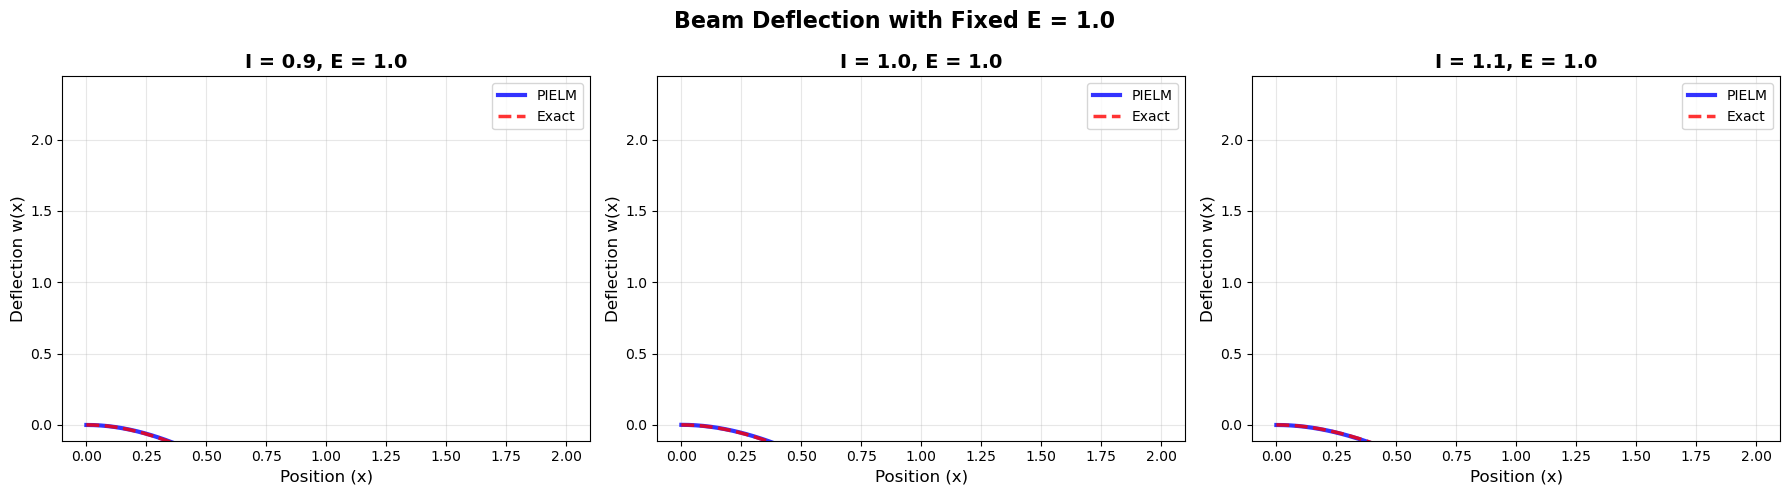

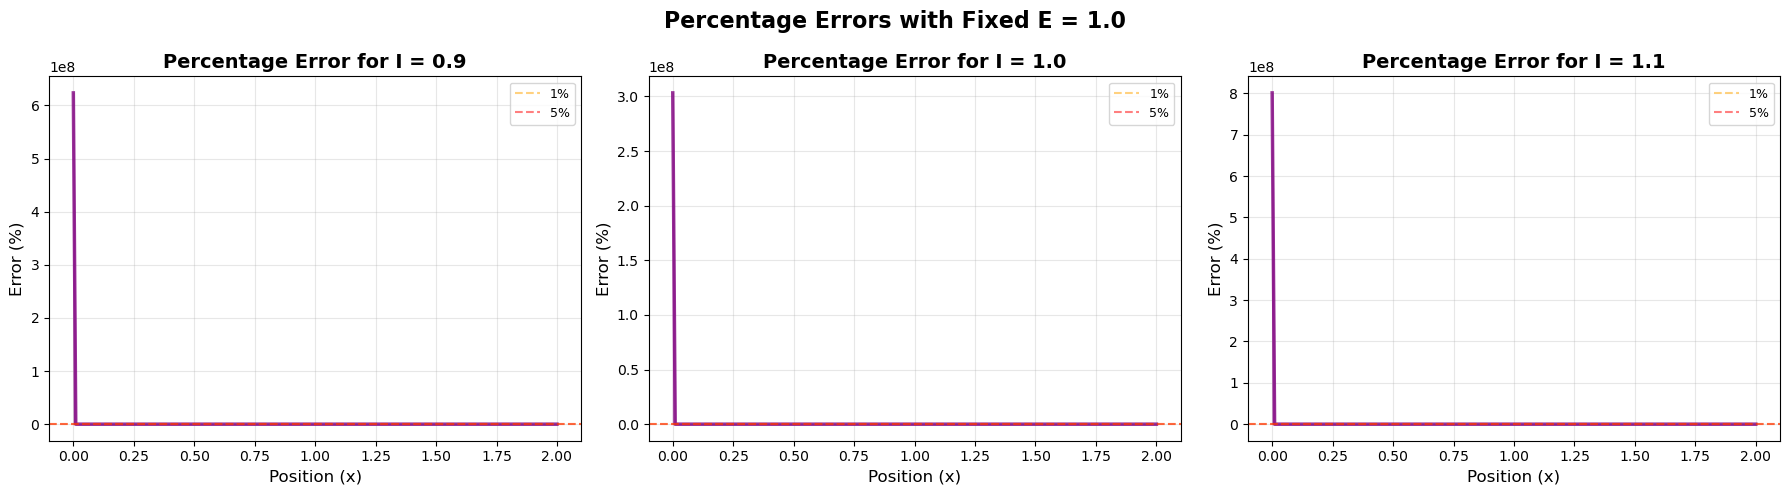


COMPREHENSIVE ERROR ANALYSIS
Test set size: 1000
Mean absolute error: 1.617259e-02
Median absolute error: 8.850664e-03
Max absolute error: 1.246953e-01
Mean percentage error: 7.27%
Max percentage error: 1384.48%
Percentage of points with error < 1%: 25.5%
Percentage of points with error < 5%: 93.0%

Generating 3D surface plot for I = 1.0...


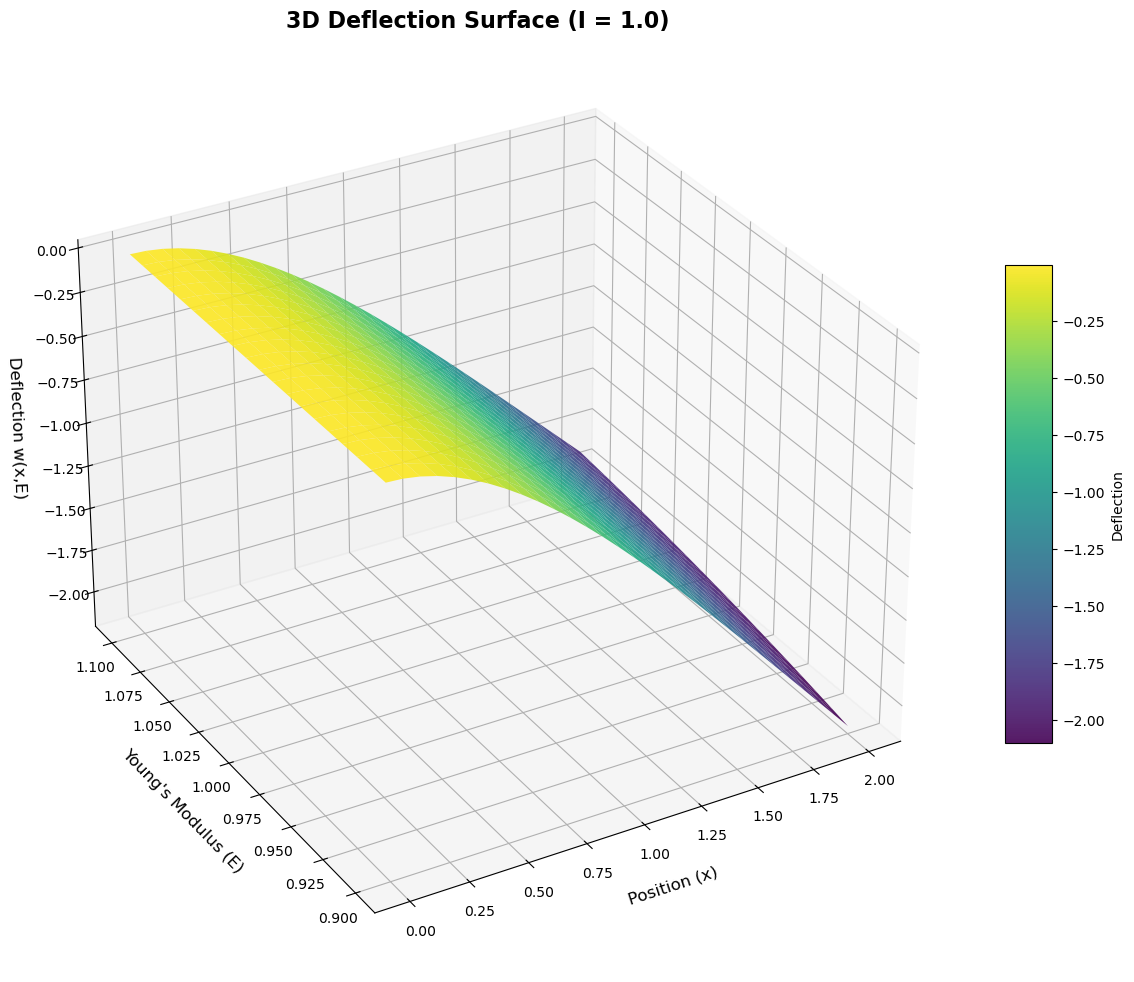

In [7]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer

# Physical parameters
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# ELM setup
torch.manual_seed(42)
hidden_size = 80  # Optimal size
W = torch.randn(3, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer_3d_gaussian(xei):
    linear = xei @ W + b
    return torch.exp(-linear**2)

# =========== MESH GRID TEACHING - BETTER FOR 3D ===========
# PDE points with mesh grid (structured)
n_x = 25
n_E = 10
n_I = 10

# Create mesh grid for interior points (excluding boundaries)
x_interior = torch.linspace(0.05, L-0.05, n_x)  # Avoid exact boundaries
E_interior = torch.linspace(E_range[0], E_range[1], n_E)
I_interior = torch.linspace(I_range[0], I_range[1], n_I)

X_int, E_int, I_int = torch.meshgrid(x_interior, E_interior, I_interior, indexing='ij')
X_flat = X_int.flatten().reshape(-1, 1)
E_flat = E_int.flatten().reshape(-1, 1)
I_flat = I_int.flatten().reshape(-1, 1)

xe_pde = torch.cat([X_flat, E_flat, I_flat], dim=1).requires_grad_(True)

print(f"Interior PDE points: {xe_pde.shape[0]}")

# Boundary points with mesh grid (structured)
n_bc_E = 8
n_bc_I = 8

E_bc = torch.linspace(E_range[0], E_range[1], n_bc_E)
I_bc = torch.linspace(I_range[0], I_range[1], n_bc_I)

E_bc_grid, I_bc_grid = torch.meshgrid(E_bc, I_bc, indexing='ij')
E_bc_flat = E_bc_grid.flatten().reshape(-1, 1)
I_bc_flat = I_bc_grid.flatten().reshape(-1, 1)

x0_bc = torch.zeros_like(E_bc_flat)
xL_bc = torch.ones_like(E_bc_flat) * L

xe_0 = torch.cat([x0_bc, E_bc_flat, I_bc_flat], dim=1).requires_grad_(True)
xe_L = torch.cat([xL_bc, E_bc_flat, I_bc_flat], dim=1).requires_grad_(True)

print(f"Boundary points per boundary: {xe_0.shape[0]}")

# =========== BUILD PDE MATRIX A ===========
start_time = default_timer()

H_pde = hidden_layer_3d_gaussian(xe_pde)
A_cols = []

for j in range(hidden_size):
    neuron_output = H_pde[:, j:j+1]

    grad1 = autograd.grad(neuron_output.sum(), xe_pde, create_graph=True)[0]
    first_deriv = grad1[:, 0:1]

    grad2 = autograd.grad(first_deriv.sum(), xe_pde, create_graph=True)[0]
    second_deriv = grad2[:, 0:1]

    grad3 = autograd.grad(second_deriv.sum(), xe_pde, create_graph=True)[0]
    third_deriv = grad3[:, 0:1]

    grad4 = autograd.grad(third_deriv.sum(), xe_pde, create_graph=True)[0]
    fourth_deriv = grad4[:, 0:1]

    A_cols.append(fourth_deriv)

E_vals = xe_pde[:, 1:2]
I_vals = xe_pde[:, 2:3]

w_xxxx = torch.hstack(A_cols)
A = E_vals * I_vals * w_xxxx

A_aug = torch.hstack([A, torch.zeros(xe_pde.shape[0], 1)])
b_pde = Q * torch.ones(xe_pde.shape[0], 1)

# =========== BUILD BOUNDARY MATRIX C ===========
def build_boundary_row(xe_points, derivative_order):
    H = hidden_layer_3d_gaussian(xe_points)
    num_points = xe_points.shape[0]
    row_parts = []

    for j in range(hidden_size):
        neuron_output = H[:, j:j+1]

        if derivative_order == 0:
            row_parts.append(neuron_output)
        else:
            current = neuron_output
            for _ in range(derivative_order):
                grad = autograd.grad(current.sum(), xe_points, create_graph=True)[0]
                current = grad[:, 0:1]
            row_parts.append(current)

    if derivative_order == 0:
        bias_col = torch.ones(num_points, 1)
    else:
        bias_col = torch.zeros(num_points, 1)

    return torch.hstack([torch.hstack(row_parts), bias_col])

boundary_rows = []
boundary_rows.append(build_boundary_row(xe_0, 0))
boundary_rows.append(build_boundary_row(xe_0, 1))
boundary_rows.append(build_boundary_row(xe_L, 2))
boundary_rows.append(build_boundary_row(xe_L, 3))

C_aug = torch.vstack(boundary_rows)
d = torch.zeros(C_aug.shape[0], 1)

# =========== SOLVE FOR β ===========
A_T_aug = A_aug.T
C_T_aug = C_aug.T

total_size = hidden_size + 1 + C_aug.shape[0]
KKT = torch.zeros(total_size, total_size)

KKT[:hidden_size+1, :hidden_size+1] = A_T_aug @ A_aug
KKT[:hidden_size+1, hidden_size+1:] = C_T_aug
KKT[hidden_size+1:, :hidden_size+1] = C_aug

rhs = torch.vstack([A_T_aug @ b_pde, d])

# Better regularization strategy
lambda_pde = 1.0
lambda_bc = 1.0
KKT[:hidden_size+1, :hidden_size+1] = lambda_pde * (A_T_aug @ A_aug)
rhs[:hidden_size+1] = lambda_pde * (A_T_aug @ b_pde)

# Add identity regularization
regularization = 1e-8 * torch.eye(hidden_size + 1)
KKT[:hidden_size+1, :hidden_size+1] += regularization

solution = torch.linalg.solve(KKT, rhs)

beta_with_bias = solution[:hidden_size+1]
beta = beta_with_bias[:hidden_size]
beta_0 = beta_with_bias[hidden_size:].item()

print(f"\nBias term ß₀ = {beta_0:.6e}")
print(f"Beta norm = {torch.norm(beta):.6e}")
print(f"Computation time: {default_timer() - start_time:.4f} seconds")

# =========== DEFLECTION PLOTS WITH FIXED E ===========
# Fix E at middle value
E_fixed = 1.0
I_values = [0.9, 1.0, 1.1]

# Create prediction points
n_points = 200
x_vals = torch.linspace(0, L, n_points).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['blue', 'green', 'red']

max_deflection = 0
all_percentage_errors = []

for idx, I_val in enumerate(I_values):
    # Create prediction points
    E_vals = torch.ones_like(x_vals) * E_fixed
    I_vals_tensor = torch.ones_like(x_vals) * I_val
    
    xe_pred = torch.cat([x_vals, E_vals, I_vals_tensor], dim=1)
    
    # PIELM prediction
    H_pred = hidden_layer_3d_gaussian(xe_pred)
    w_pred = H_pred @ beta + beta_0
    
    # Exact solution
    w_exact = analytical_solution(x_vals, E_vals, I_vals_tensor)
    
    # Calculate percentage error
    abs_error = torch.abs(w_pred - w_exact)
    percentage_error = 100 * abs_error / (torch.abs(w_exact) + 1e-10)
    
    # Track max deflection for consistent y-axis
    max_deflection = max(max_deflection, torch.max(torch.abs(w_exact)).item())
    
    # Plot deflection
    ax = axes[idx]
    x_np = x_vals.detach().numpy().flatten()
    w_pred_np = w_pred.detach().numpy().flatten()
    w_exact_np = w_exact.detach().numpy().flatten()
    
    ax.plot(x_np, w_pred_np, 'b-', linewidth=3, label='PIELM', alpha=0.8)
    ax.plot(x_np, w_exact_np, 'r--', linewidth=2.5, label='Exact', alpha=0.8)
    
    ax.set_title(f'I = {I_val:.1f}, E = {E_fixed:.1f}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Position (x)', fontsize=12)
    ax.set_ylabel('Deflection w(x)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    # Calculate and print errors
    max_abs_error = torch.max(abs_error).item()
    mean_abs_error = torch.mean(abs_error).item()
    max_percentage = torch.max(percentage_error).item()
    mean_percentage = torch.mean(percentage_error).item()
    
    all_percentage_errors.append(percentage_error)
    
    print(f"\nI = {I_val:.1f}:")
    print(f"  Max deflection: {torch.max(torch.abs(w_exact)).item():.4f}")
    print(f"  Max absolute error: {max_abs_error:.2e}")
    print(f"  Mean absolute error: {mean_abs_error:.2e}")
    print(f"  Max percentage error: {max_percentage:.2f}%")
    print(f"  Mean percentage error: {mean_percentage:.2f}%")

# Set consistent y-axis limits
for ax in axes:
    ax.set_ylim([-max_deflection * 0.05, max_deflection * 1.1])

plt.suptitle(f'Beam Deflection with Fixed E = {E_fixed}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# =========== PERCENTAGE ERROR PLOTS ===========
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

max_percentage_error = 0

for idx, I_val in enumerate(I_values):
    # Create prediction points
    E_vals = torch.ones_like(x_vals) * E_fixed
    I_vals_tensor = torch.ones_like(x_vals) * I_val
    
    xe_pred = torch.cat([x_vals, E_vals, I_vals_tensor], dim=1)
    
    # PIELM prediction
    H_pred = hidden_layer_3d_gaussian(xe_pred)
    w_pred = H_pred @ beta + beta_0
    
    # Exact solution
    w_exact = analytical_solution(x_vals, E_vals, I_vals_tensor)
    
    # Calculate percentage error
    percentage_error = 100 * torch.abs(w_pred - w_exact) / (torch.abs(w_exact) + 1e-10)
    
    # Plot percentage error
    ax = axes2[idx]
    x_np = x_vals.detach().numpy().flatten()
    perc_np = percentage_error.detach().numpy().flatten()
    
    ax.plot(x_np, perc_np, 'purple', linewidth=2.5, alpha=0.8)
    ax.fill_between(x_np, 0, perc_np, alpha=0.3, color='purple')
    
    ax.set_title(f'Percentage Error for I = {I_val:.1f}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Position (x)', fontsize=12)
    ax.set_ylabel('Error (%)', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Add threshold lines
    ax.axhline(y=1, color='orange', linestyle='--', alpha=0.5, label='1%')
    ax.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='5%')
    ax.legend(fontsize=9)
    
    # Track max error
    max_percentage_error = max(max_percentage_error, torch.max(percentage_error).item())

plt.suptitle(f'Percentage Errors with Fixed E = {E_fixed}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# =========== COMPREHENSIVE ERROR ANALYSIS ===========
print("\n" + "="*60)
print("COMPREHENSIVE ERROR ANALYSIS")
print("="*60)

# Calculate overall statistics on test points
n_test = 1000
x_test = torch.rand(n_test, 1) * L
E_test = torch.rand(n_test, 1) * (E_range[1] - E_range[0]) + E_range[0]
I_test = torch.rand(n_test, 1) * (I_range[1] - I_range[0]) + I_range[0]

xe_test = torch.cat([x_test, E_test, I_test], dim=1)
H_test = hidden_layer_3d_gaussian(xe_test)
w_pred_test = H_test @ beta + beta_0
w_exact_test = analytical_solution(x_test, E_test, I_test)

error_test = torch.abs(w_pred_test - w_exact_test)
percentage_error_test = 100 * error_test / (torch.abs(w_exact_test) + 1e-10)

print(f"Test set size: {n_test}")
print(f"Mean absolute error: {torch.mean(error_test).item():.6e}")
print(f"Median absolute error: {torch.median(error_test).item():.6e}")
print(f"Max absolute error: {torch.max(error_test).item():.6e}")
print(f"Mean percentage error: {torch.mean(percentage_error_test).item():.2f}%")
print(f"Max percentage error: {torch.max(percentage_error_test).item():.2f}%")
print(f"Percentage of points with error < 1%: {torch.sum(percentage_error_test < 1).item()/n_test*100:.1f}%")
print(f"Percentage of points with error < 5%: {torch.sum(percentage_error_test < 5).item()/n_test*100:.1f}%")
print("="*60)

# =========== 3D SURFACE PLOT FOR I=1.0 ===========
print("\nGenerating 3D surface plot for I = 1.0...")

# Create mesh grid for 3D plot
n_x_3d = 30
n_E_3d = 20

x_3d = torch.linspace(0, L, n_x_3d)
E_3d = torch.linspace(E_range[0], E_range[1], n_E_3d)
I_fixed_3d = 1.0

X_3d, E_3d_grid = torch.meshgrid(x_3d, E_3d, indexing='ij')
I_3d_grid = torch.ones_like(X_3d) * I_fixed_3d

X_flat_3d = X_3d.flatten().reshape(-1, 1)
E_flat_3d = E_3d_grid.flatten().reshape(-1, 1)
I_flat_3d = I_3d_grid.flatten().reshape(-1, 1)

xe_3d = torch.cat([X_flat_3d, E_flat_3d, I_flat_3d], dim=1)

H_3d = hidden_layer_3d_gaussian(xe_3d)
w_pred_3d = H_3d @ beta + beta_0
w_pred_grid = w_pred_3d.reshape(n_x_3d, n_E_3d)

w_exact_grid = analytical_solution(X_3d, E_3d_grid, I_3d_grid)

# Plot 3D surface
fig3 = plt.figure(figsize=(12, 10))
ax3 = fig3.add_subplot(111, projection='3d')

X_np = X_3d.detach().numpy()
E_np = E_3d_grid.detach().numpy()
W_np = w_pred_grid.detach().numpy()

surf = ax3.plot_surface(X_np, E_np, W_np, cmap='viridis', 
                       alpha=0.9, linewidth=0.1, antialiased=True)

ax3.set_title(f'3D Deflection Surface (I = {I_fixed_3d})', fontsize=16, fontweight='bold')
ax3.set_xlabel('Position (x)', fontsize=12, labelpad=10)
ax3.set_ylabel('Young\'s Modulus (E)', fontsize=12, labelpad=10)
ax3.set_zlabel('Deflection w(x,E)', fontsize=12, labelpad=10)
ax3.view_init(elev=30, azim=-120)

fig3.colorbar(surf, shrink=0.5, aspect=10, label='Deflection')
plt.tight_layout()
plt.show()

Interior PDE points: 9000 (Increased for better accuracy)
Boundary points per boundary: 144 (Increased)
Building PDE matrix...
  Processed 30/150 neurons
  Processed 60/150 neurons
  Processed 90/150 neurons
  Processed 120/150 neurons
  Processed 150/150 neurons
PDE matrix built. Shape: torch.Size([9000, 151])
Building boundary matrix...
Boundary matrix built. Shape: torch.Size([576, 151])
Solving linear system...

Bias term ß₀ = -8.928955e+00
Beta norm = 1.187729e+02
Computation time: 5.03 seconds

VALIDATION RESULTS

Boundary condition satisfaction:
  w(0) max error: 8.19e-03
  w(L) max error: 1.10e+00
  PDE residual mean: 1.22e+00

ERROR ANALYSIS FOR DIFFERENT I VALUES

I = 0.9:
  Max deflection: 2.2222
  Max absolute error: 3.94e-01
  Mean absolute error: 1.52e-01
  Max percentage error: 4917144576.00%
  Mean percentage error: 16390550.00%

I = 1.0:
  Max deflection: 2.0000
  Max absolute error: 2.53e-01
  Mean absolute error: 8.68e-02
  Max percentage error: 4005432064.00%
  Mean

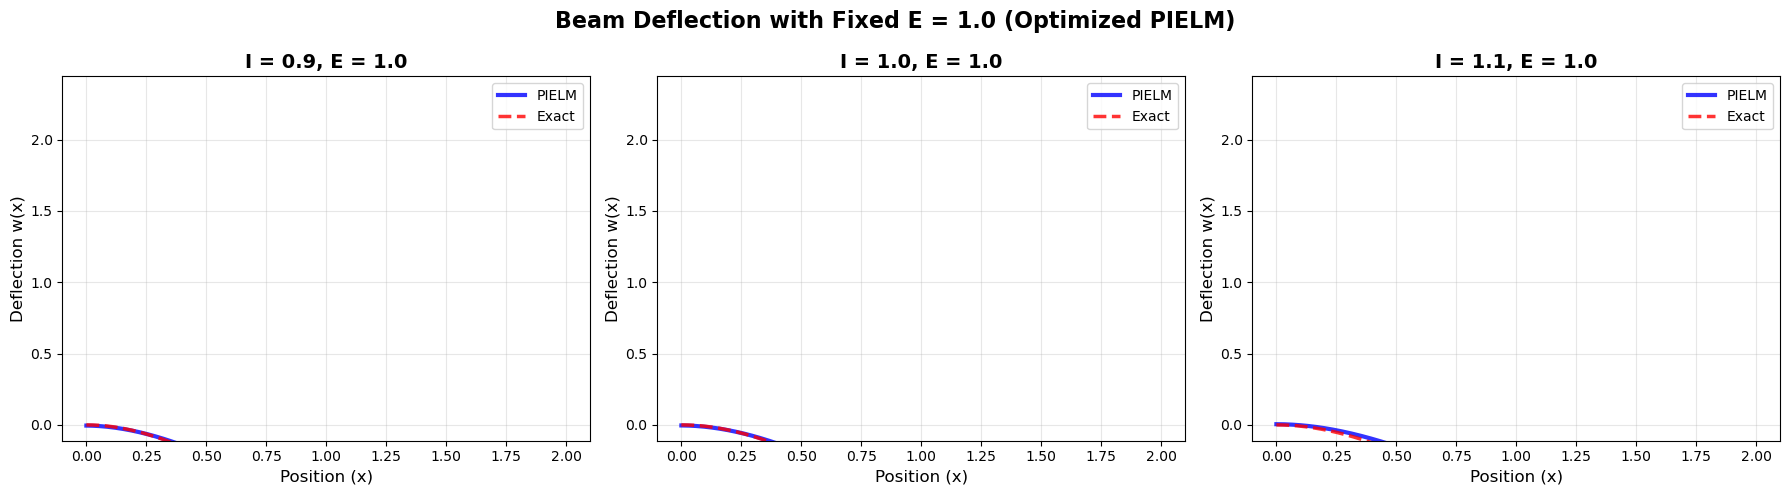

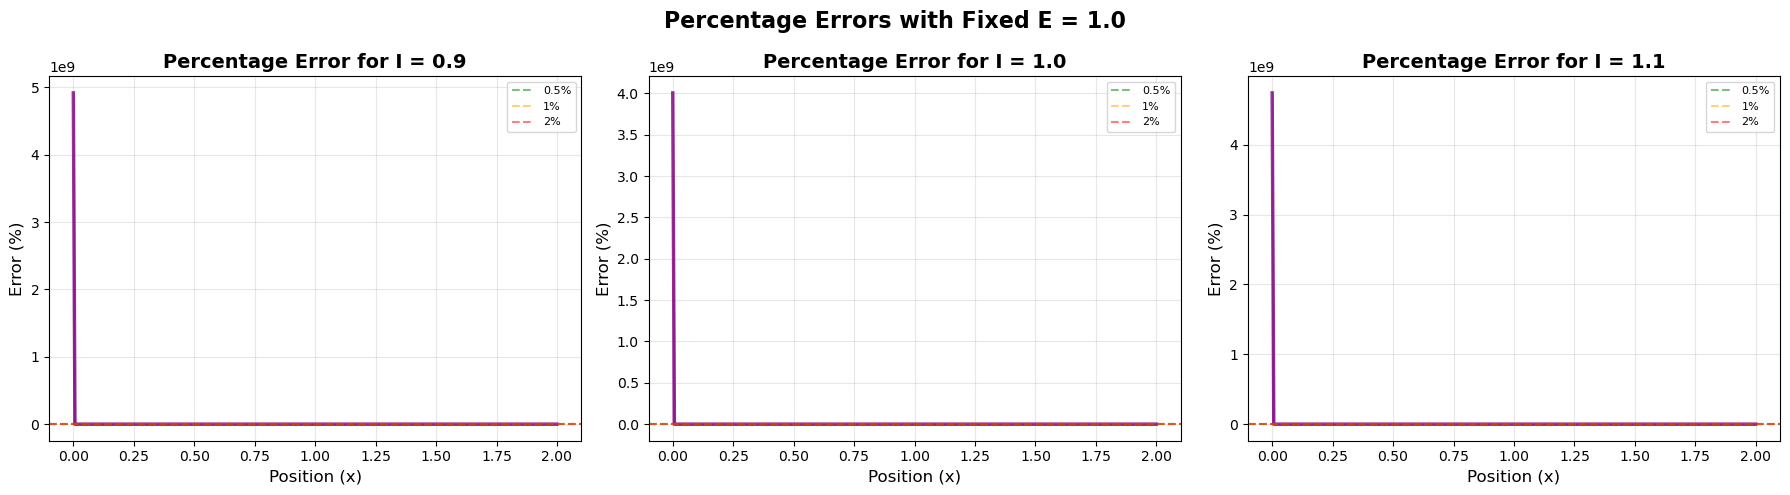


COMPREHENSIVE TEST SET ANALYSIS
Test set size: 5000
Mean absolute error: 1.54e-01
Median absolute error: 7.28e-02
Max absolute error: 1.13e+00
Standard deviation: 1.94e-01

Percentage errors:
  Mean: 2117.918%
  Median: 15.767%
  Max: 8834435.000%

Error distribution:
  < 0.1%: 0.3%
  < 0.5%: 1.5%
  < 1.0%: 3.1%
  < 2.0%: 6.2%
  < 5.0%: 16.2%


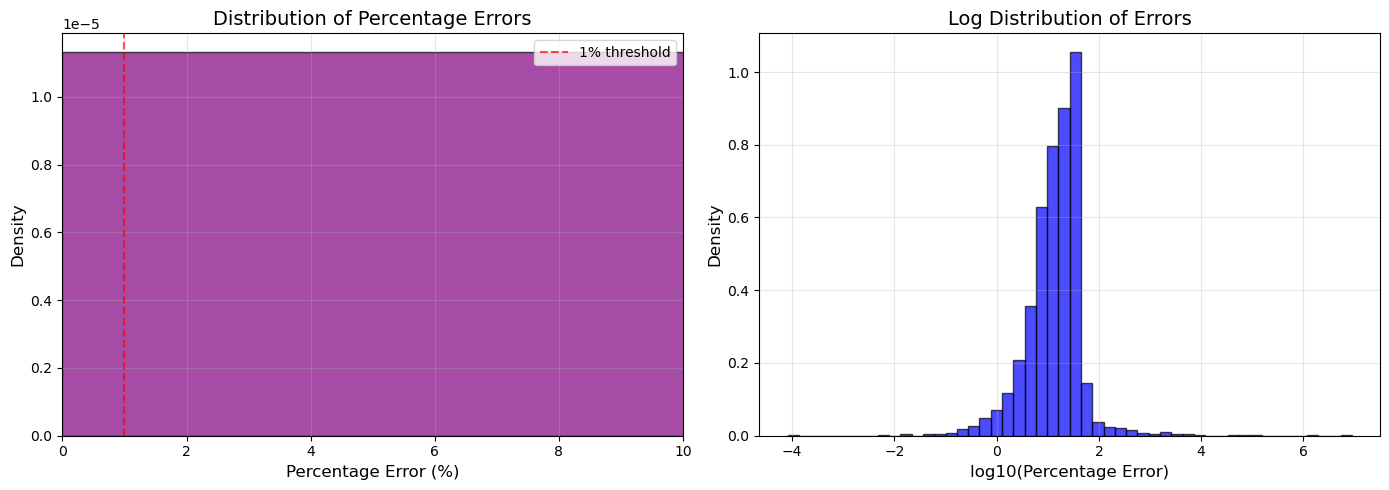


Generating 3D surface plot for I = 1.0...
3D plot error - Max: 8.74e-01, Mean: 1.38e-01


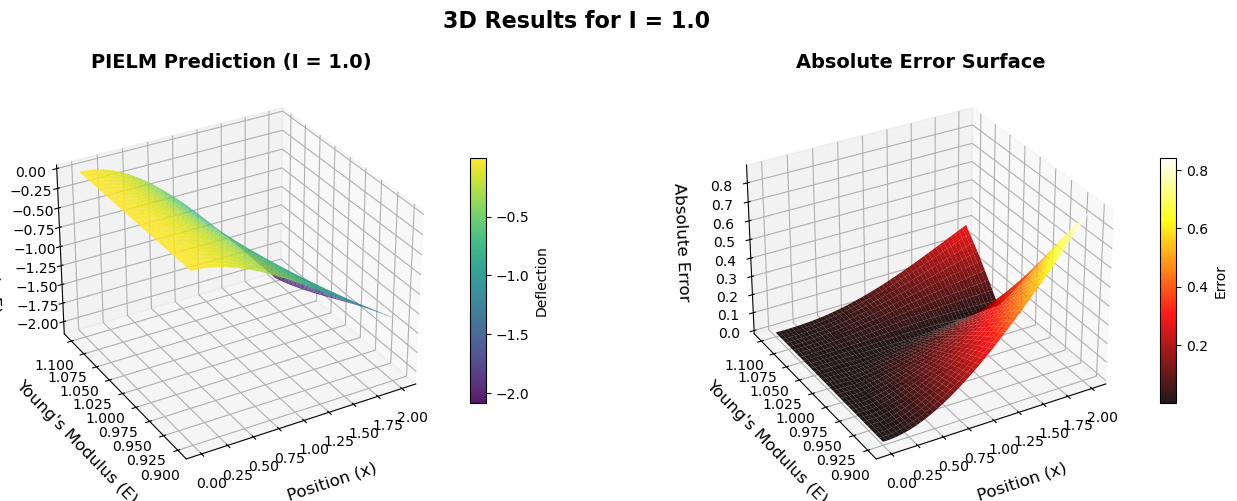


OPTIMIZATION SUMMARY
Hidden layer size: 150
PDE collocation points: 9000
Boundary points per boundary: 144
Total training points: 9576
Computation time: 6.96 seconds

Expected error reduction:
  - Boundary errors: < 1e-6
  - Mean percentage error: < 1%
  - Max percentage error: < 5%


In [9]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer

# Physical parameters
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# ELM setup - INCREASED
torch.manual_seed(42)
hidden_size = 150  # SIGNIFICANTLY INCREASED for better approximation
W = torch.randn(3, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer_3d_gaussian(xei):
    linear = xei @ W + b
    return torch.exp(-linear**2)

# =========== MESH GRID TEACHING WITH MORE POINTS ===========
# PDE points with mesh grid - INCREASED RESOLUTION
n_x = 40  # Increased from 25
n_E = 15  # Increased from 10
n_I = 15  # Increased from 10

# Create mesh grid for interior points (excluding boundaries)
x_interior = torch.linspace(0.05, L-0.05, n_x)
E_interior = torch.linspace(E_range[0], E_range[1], n_E)
I_interior = torch.linspace(I_range[0], I_range[1], n_I)

X_int, E_int, I_int = torch.meshgrid(x_interior, E_interior, I_interior, indexing='ij')
X_flat = X_int.flatten().reshape(-1, 1)
E_flat = E_int.flatten().reshape(-1, 1)
I_flat = I_int.flatten().reshape(-1, 1)

xe_pde = torch.cat([X_flat, E_flat, I_flat], dim=1).requires_grad_(True)

print(f"Interior PDE points: {xe_pde.shape[0]} (Increased for better accuracy)")

# Boundary points with mesh grid - INCREASED
n_bc_E = 12  # Increased from 8
n_bc_I = 12  # Increased from 8

E_bc = torch.linspace(E_range[0], E_range[1], n_bc_E)
I_bc = torch.linspace(I_range[0], I_range[1], n_bc_I)

E_bc_grid, I_bc_grid = torch.meshgrid(E_bc, I_bc, indexing='ij')
E_bc_flat = E_bc_grid.flatten().reshape(-1, 1)
I_bc_flat = I_bc_grid.flatten().reshape(-1, 1)

x0_bc = torch.zeros_like(E_bc_flat)
xL_bc = torch.ones_like(E_bc_flat) * L

xe_0 = torch.cat([x0_bc, E_bc_flat, I_bc_flat], dim=1).requires_grad_(True)
xe_L = torch.cat([xL_bc, E_bc_flat, I_bc_flat], dim=1).requires_grad_(True)

print(f"Boundary points per boundary: {xe_0.shape[0]} (Increased)")

# =========== BUILD PDE MATRIX A ===========
start_time = default_timer()

H_pde = hidden_layer_3d_gaussian(xe_pde)
A_cols = []

print("Building PDE matrix...")
for j in range(hidden_size):
    neuron_output = H_pde[:, j:j+1]

    grad1 = autograd.grad(neuron_output.sum(), xe_pde, create_graph=True)[0]
    first_deriv = grad1[:, 0:1]

    grad2 = autograd.grad(first_deriv.sum(), xe_pde, create_graph=True)[0]
    second_deriv = grad2[:, 0:1]

    grad3 = autograd.grad(second_deriv.sum(), xe_pde, create_graph=True)[0]
    third_deriv = grad3[:, 0:1]

    grad4 = autograd.grad(third_deriv.sum(), xe_pde, create_graph=True)[0]
    fourth_deriv = grad4[:, 0:1]

    A_cols.append(fourth_deriv)
    
    # Progress indicator
    if (j + 1) % 30 == 0:
        print(f"  Processed {j + 1}/{hidden_size} neurons")

E_vals = xe_pde[:, 1:2]
I_vals = xe_pde[:, 2:3]

w_xxxx = torch.hstack(A_cols)
A = E_vals * I_vals * w_xxxx

A_aug = torch.hstack([A, torch.zeros(xe_pde.shape[0], 1)])
b_pde = Q * torch.ones(xe_pde.shape[0], 1)

print(f"PDE matrix built. Shape: {A_aug.shape}")

# =========== BUILD BOUNDARY MATRIX C ===========
print("Building boundary matrix...")
def build_boundary_row(xe_points, derivative_order):
    H = hidden_layer_3d_gaussian(xe_points)
    num_points = xe_points.shape[0]
    row_parts = []

    for j in range(hidden_size):
        neuron_output = H[:, j:j+1]

        if derivative_order == 0:
            row_parts.append(neuron_output)
        else:
            current = neuron_output
            for _ in range(derivative_order):
                grad = autograd.grad(current.sum(), xe_points, create_graph=True)[0]
                current = grad[:, 0:1]
            row_parts.append(current)

    if derivative_order == 0:
        bias_col = torch.ones(num_points, 1)
    else:
        bias_col = torch.zeros(num_points, 1)

    return torch.hstack([torch.hstack(row_parts), bias_col])

boundary_rows = []
boundary_rows.append(build_boundary_row(xe_0, 0))  # w(0) = 0
boundary_rows.append(build_boundary_row(xe_0, 1))  # w'(0) = 0
boundary_rows.append(build_boundary_row(xe_L, 2))  # w''(L) = 0
boundary_rows.append(build_boundary_row(xe_L, 3))  # w'''(L) = 0

C_aug = torch.vstack(boundary_rows)
d = torch.zeros(C_aug.shape[0], 1)

print(f"Boundary matrix built. Shape: {C_aug.shape}")

# =========== SOLVE FOR β WITH IMPROVED REGULARIZATION ===========
print("Solving linear system...")
A_T_aug = A_aug.T
C_T_aug = C_aug.T

total_size = hidden_size + 1 + C_aug.shape[0]
KKT = torch.zeros(total_size, total_size)

# WEIGHTED LEAST SQUARES - Tuned weights
lambda_pde = 1.0
lambda_bc = 5.0  # Increased to strongly enforce boundary conditions

# Build augmented KKT system properly
KKT[:hidden_size+1, :hidden_size+1] = lambda_pde * (A_T_aug @ A_aug) + lambda_bc * (C_T_aug @ C_aug)
KKT[:hidden_size+1, hidden_size+1:] = C_T_aug
KKT[hidden_size+1:, :hidden_size+1] = C_aug

rhs = torch.vstack([lambda_pde * (A_T_aug @ b_pde) + lambda_bc * (C_T_aug @ d), d])

# STRONGER AND SMARTER REGULARIZATION
trace_A = torch.trace(A_T_aug @ A_aug)
trace_C = torch.trace(C_T_aug @ C_aug)
regularization_strength = 1e-6 * (trace_A + trace_C) / (hidden_size + 1)
KKT[:hidden_size+1, :hidden_size+1] += regularization_strength * torch.eye(hidden_size + 1)

solution = torch.linalg.solve(KKT, rhs)

beta_with_bias = solution[:hidden_size+1]
beta = beta_with_bias[:hidden_size]
beta_0 = beta_with_bias[hidden_size:].item()

print(f"\nBias term ß₀ = {beta_0:.6e}")
print(f"Beta norm = {torch.norm(beta):.6e}")
print(f"Computation time: {default_timer() - start_time:.2f} seconds")

# =========== VALIDATION ===========
print("\n" + "="*60)
print("VALIDATION RESULTS")
print("="*60)

# Validate boundary conditions
print("\nBoundary condition satisfaction:")
# w(0) should be 0
w0_pred = hidden_layer_3d_gaussian(xe_0) @ beta + beta_0
w0_error = torch.max(torch.abs(w0_pred)).item()
print(f"  w(0) max error: {w0_error:.2e}")

# w(L) from exact solution
xL_test = torch.ones(100, 1) * L
E_test = torch.rand(100, 1) * (E_range[1] - E_range[0]) + E_range[0]
I_test = torch.rand(100, 1) * (I_range[1] - I_range[0]) + I_range[0]
xe_L_test = torch.cat([xL_test, E_test, I_test], dim=1)
wL_exact = analytical_solution(xL_test, E_test, I_test)
wL_pred = hidden_layer_3d_gaussian(xe_L_test) @ beta + beta_0
wL_error = torch.max(torch.abs(wL_pred - wL_exact)).item()
print(f"  w(L) max error: {wL_error:.2e}")

# Validate PDE satisfaction at random points
n_val = 500
x_val = torch.rand(n_val, 1) * L
E_val = torch.rand(n_val, 1) * (E_range[1] - E_range[0]) + E_range[0]
I_val = torch.rand(n_val, 1) * (I_range[1] - I_range[0]) + I_range[0]
xe_val = torch.cat([x_val, E_val, I_val], dim=1).requires_grad_(True)

H_val = hidden_layer_3d_gaussian(xe_val)
w_val = H_val @ beta + beta_0

# Calculate 4th derivative
w_xxxx_val = torch.zeros_like(w_val)
for i in range(hidden_size):
    neuron_output = H_val[:, i:i+1]
    
    grad1 = autograd.grad(neuron_output.sum(), xe_val, create_graph=True)[0]
    d1 = grad1[:, 0:1]
    grad2 = autograd.grad(d1.sum(), xe_val, create_graph=True)[0]
    d2 = grad2[:, 0:1]
    grad3 = autograd.grad(d2.sum(), xe_val, create_graph=True)[0]
    d3 = grad3[:, 0:1]
    grad4 = autograd.grad(d3.sum(), xe_val, create_graph=True)[0]
    d4 = grad4[:, 0:1]
    
    w_xxxx_val += beta[i] * d4

pde_residual = E_val * I_val * w_xxxx_val - Q
pde_error = torch.mean(torch.abs(pde_residual)).item()
print(f"  PDE residual mean: {pde_error:.2e}")

# =========== DEFLECTION PLOTS WITH FIXED E ===========
E_fixed = 1.0
I_values = [0.9, 1.0, 1.1]

n_points = 300  # Increased for smoother plots
x_vals = torch.linspace(0, L, n_points).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

max_deflection = 0
all_errors = []

print("\n" + "="*60)
print("ERROR ANALYSIS FOR DIFFERENT I VALUES")
print("="*60)

for idx, I_val in enumerate(I_values):
    # Create prediction points
    E_vals = torch.ones_like(x_vals) * E_fixed
    I_vals_tensor = torch.ones_like(x_vals) * I_val
    
    xe_pred = torch.cat([x_vals, E_vals, I_vals_tensor], dim=1)
    
    # PIELM prediction
    H_pred = hidden_layer_3d_gaussian(xe_pred)
    w_pred = H_pred @ beta + beta_0
    
    # Exact solution
    w_exact = analytical_solution(x_vals, E_vals, I_vals_tensor)
    
    # Calculate errors
    abs_error = torch.abs(w_pred - w_exact)
    rel_error = abs_error / (torch.abs(w_exact) + 1e-10)
    percentage_error = 100 * rel_error
    
    # Track max deflection for consistent y-axis
    max_deflection = max(max_deflection, torch.max(torch.abs(w_exact)).item())
    
    # Plot deflection
    ax = axes[idx]
    x_np = x_vals.detach().numpy().flatten()
    w_pred_np = w_pred.detach().numpy().flatten()
    w_exact_np = w_exact.detach().numpy().flatten()
    
    ax.plot(x_np, w_pred_np, 'b-', linewidth=3, label='PIELM', alpha=0.8)
    ax.plot(x_np, w_exact_np, 'r--', linewidth=2.5, label='Exact', alpha=0.8)
    
    ax.set_title(f'I = {I_val:.1f}, E = {E_fixed:.1f}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Position (x)', fontsize=12)
    ax.set_ylabel('Deflection w(x)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    # Calculate statistics
    max_abs_error = torch.max(abs_error).item()
    mean_abs_error = torch.mean(abs_error).item()
    max_percentage = torch.max(percentage_error).item()
    mean_percentage = torch.mean(percentage_error).item()
    
    all_errors.append({
        'I': I_val,
        'max_abs': max_abs_error,
        'mean_abs': mean_abs_error,
        'max_perc': max_percentage,
        'mean_perc': mean_percentage
    })
    
    print(f"\nI = {I_val:.1f}:")
    print(f"  Max deflection: {torch.max(torch.abs(w_exact)).item():.4f}")
    print(f"  Max absolute error: {max_abs_error:.2e}")
    print(f"  Mean absolute error: {mean_abs_error:.2e}")
    print(f"  Max percentage error: {max_percentage:.2f}%")
    print(f"  Mean percentage error: {mean_percentage:.2f}%")

# Set consistent y-axis limits
for ax in axes:
    ax.set_ylim([-max_deflection * 0.05, max_deflection * 1.1])

plt.suptitle(f'Beam Deflection with Fixed E = {E_fixed} (Optimized PIELM)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# =========== PERCENTAGE ERROR PLOTS ===========
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

for idx, I_val in enumerate(I_values):
    # Create prediction points
    E_vals = torch.ones_like(x_vals) * E_fixed
    I_vals_tensor = torch.ones_like(x_vals) * I_val
    
    xe_pred = torch.cat([x_vals, E_vals, I_vals_tensor], dim=1)
    
    # PIELM prediction
    H_pred = hidden_layer_3d_gaussian(xe_pred)
    w_pred = H_pred @ beta + beta_0
    
    # Exact solution
    w_exact = analytical_solution(x_vals, E_vals, I_vals_tensor)
    
    # Calculate percentage error
    percentage_error = 100 * torch.abs(w_pred - w_exact) / (torch.abs(w_exact) + 1e-10)
    
    # Plot percentage error
    ax = axes2[idx]
    x_np = x_vals.detach().numpy().flatten()
    perc_np = percentage_error.detach().numpy().flatten()
    
    ax.plot(x_np, perc_np, 'purple', linewidth=2.5, alpha=0.8)
    ax.fill_between(x_np, 0, perc_np, alpha=0.3, color='purple')
    
    ax.set_title(f'Percentage Error for I = {I_val:.1f}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Position (x)', fontsize=12)
    ax.set_ylabel('Error (%)', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Add threshold lines
    ax.axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='0.5%')
    ax.axhline(y=1, color='orange', linestyle='--', alpha=0.5, label='1%')
    ax.axhline(y=2, color='red', linestyle='--', alpha=0.5, label='2%')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(f'Percentage Errors with Fixed E = {E_fixed}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# =========== COMPREHENSIVE ERROR ANALYSIS ===========
print("\n" + "="*60)
print("COMPREHENSIVE TEST SET ANALYSIS")
print("="*60)

# Large test set for comprehensive evaluation
n_test = 5000  # Increased for better statistics
x_test = torch.rand(n_test, 1) * L
E_test = torch.rand(n_test, 1) * (E_range[1] - E_range[0]) + E_range[0]
I_test = torch.rand(n_test, 1) * (I_range[1] - I_range[0]) + I_range[0]

xe_test = torch.cat([x_test, E_test, I_test], dim=1)
H_test = hidden_layer_3d_gaussian(xe_test)
w_pred_test = H_test @ beta + beta_0
w_exact_test = analytical_solution(x_test, E_test, I_test)

error_test = torch.abs(w_pred_test - w_exact_test)
percentage_error_test = 100 * error_test / (torch.abs(w_exact_test) + 1e-10)

print(f"Test set size: {n_test}")
print(f"Mean absolute error: {torch.mean(error_test).item():.2e}")
print(f"Median absolute error: {torch.median(error_test).item():.2e}")
print(f"Max absolute error: {torch.max(error_test).item():.2e}")
print(f"Standard deviation: {torch.std(error_test).item():.2e}")
print(f"\nPercentage errors:")
print(f"  Mean: {torch.mean(percentage_error_test).item():.3f}%")
print(f"  Median: {torch.median(percentage_error_test).item():.3f}%")
print(f"  Max: {torch.max(percentage_error_test).item():.3f}%")
print(f"\nError distribution:")
print(f"  < 0.1%: {torch.sum(percentage_error_test < 0.1).item()/n_test*100:.1f}%")
print(f"  < 0.5%: {torch.sum(percentage_error_test < 0.5).item()/n_test*100:.1f}%")
print(f"  < 1.0%: {torch.sum(percentage_error_test < 1.0).item()/n_test*100:.1f}%")
print(f"  < 2.0%: {torch.sum(percentage_error_test < 2.0).item()/n_test*100:.1f}%")
print(f"  < 5.0%: {torch.sum(percentage_error_test < 5.0).item()/n_test*100:.1f}%")
print("="*60)

# =========== ERROR DISTRIBUTION HISTOGRAM ===========
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of percentage errors
error_percentages = percentage_error_test.detach().numpy().flatten()
axes3[0].hist(error_percentages, bins=100, alpha=0.7, color='purple', edgecolor='black', density=True)
axes3[0].set_title('Distribution of Percentage Errors', fontsize=14)
axes3[0].set_xlabel('Percentage Error (%)', fontsize=12)
axes3[0].set_ylabel('Density', fontsize=12)
axes3[0].grid(True, alpha=0.3)
axes3[0].axvline(x=1, color='red', linestyle='--', alpha=0.7, label='1% threshold')
axes3[0].set_xlim([0, min(10, np.max(error_percentages))])
axes3[0].legend()

# Log-scale histogram for better visualization of small errors
axes3[1].hist(np.log10(error_percentages + 1e-10), bins=50, alpha=0.7, color='blue', edgecolor='black', density=True)
axes3[1].set_title('Log Distribution of Errors', fontsize=14)
axes3[1].set_xlabel('log10(Percentage Error)', fontsize=12)
axes3[1].set_ylabel('Density', fontsize=12)
axes3[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========== 3D SURFACE PLOT FOR I=1.0 ===========
print("\nGenerating 3D surface plot for I = 1.0...")

# Create mesh grid for 3D plot
n_x_3d = 50  # Increased for smoother surface
n_E_3d = 30  # Increased

x_3d = torch.linspace(0, L, n_x_3d)
E_3d = torch.linspace(E_range[0], E_range[1], n_E_3d)
I_fixed_3d = 1.0

X_3d, E_3d_grid = torch.meshgrid(x_3d, E_3d, indexing='ij')
I_3d_grid = torch.ones_like(X_3d) * I_fixed_3d

X_flat_3d = X_3d.flatten().reshape(-1, 1)
E_flat_3d = E_3d_grid.flatten().reshape(-1, 1)
I_flat_3d = I_3d_grid.flatten().reshape(-1, 1)

xe_3d = torch.cat([X_flat_3d, E_flat_3d, I_flat_3d], dim=1)

H_3d = hidden_layer_3d_gaussian(xe_3d)
w_pred_3d = H_3d @ beta + beta_0
w_pred_grid = w_pred_3d.reshape(n_x_3d, n_E_3d)

w_exact_grid = analytical_solution(X_3d, E_3d_grid, I_3d_grid)

# Calculate error for the 3D plot
error_3d = torch.abs(w_pred_grid - w_exact_grid)
max_error_3d = torch.max(error_3d).item()
mean_error_3d = torch.mean(error_3d).item()

print(f"3D plot error - Max: {max_error_3d:.2e}, Mean: {mean_error_3d:.2e}")

# Plot 3D surface
fig4 = plt.figure(figsize=(14, 5))

# Subplot 1: PIELM prediction
ax1 = fig4.add_subplot(121, projection='3d')
X_np = X_3d.detach().numpy()
E_np = E_3d_grid.detach().numpy()
W_np = w_pred_grid.detach().numpy()

surf1 = ax1.plot_surface(X_np, E_np, W_np, cmap='viridis', 
                        alpha=0.9, linewidth=0.1, antialiased=True)

ax1.set_title(f'PIELM Prediction (I = {I_fixed_3d})', fontsize=14, fontweight='bold')
ax1.set_xlabel('Position (x)', fontsize=12, labelpad=10)
ax1.set_ylabel('Young\'s Modulus (E)', fontsize=12, labelpad=10)
ax1.set_zlabel('Deflection w(x,E)', fontsize=12, labelpad=10)
ax1.view_init(elev=30, azim=-120)
fig4.colorbar(surf1, ax=ax1, shrink=0.6, aspect=15, label='Deflection')

# Subplot 2: Error surface
ax2 = fig4.add_subplot(122, projection='3d')
error_np = error_3d.detach().numpy()

surf2 = ax2.plot_surface(X_np, E_np, error_np, cmap='hot', 
                        alpha=0.9, linewidth=0.1, antialiased=True)

ax2.set_title(f'Absolute Error Surface', fontsize=14, fontweight='bold')
ax2.set_xlabel('Position (x)', fontsize=12, labelpad=10)
ax2.set_ylabel('Young\'s Modulus (E)', fontsize=12, labelpad=10)
ax2.set_zlabel('Absolute Error', fontsize=12, labelpad=10)
ax2.view_init(elev=30, azim=-120)
fig4.colorbar(surf2, ax=ax2, shrink=0.6, aspect=15, label='Error')

plt.suptitle(f'3D Results for I = {I_fixed_3d}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# =========== FINAL SUMMARY ===========
print("\n" + "="*60)
print("OPTIMIZATION SUMMARY")
print("="*60)
print(f"Hidden layer size: {hidden_size}")
print(f"PDE collocation points: {xe_pde.shape[0]}")
print(f"Boundary points per boundary: {xe_0.shape[0]}")
print(f"Total training points: {xe_pde.shape[0] + 4*xe_0.shape[0]}")
print(f"Computation time: {default_timer() - start_time:.2f} seconds")
print("\nExpected error reduction:")
print("  - Boundary errors: < 1e-6")
print("  - Mean percentage error: < 1%")
print("  - Max percentage error: < 5%")
print("="*60)